In [35]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset


In [36]:
# ==========================================
# 2. Data Loading & Cleaning
# ==========================================
df_raw = pd.read_csv('datasets/COMBINED DATASET - Sheet1.csv', skiprows=1)
df_raw.columns = df_raw.columns.str.strip()

df_clean = pd.DataFrame()
df_clean['Time_Min'] = pd.to_numeric(df_raw.iloc[:, 1], errors='coerce')
df_clean['Radiation'] = pd.to_numeric(df_raw['2  Pyra02_B [W/m2]'], errors='coerce')
df_clean['Temperature'] = pd.to_numeric(df_raw['AuNF-Tarap'], errors='coerce')
df_clean = df_clean.dropna().reset_index(drop=True)

In [43]:
# ==========================================
# 3. Feature Engineering (20-Minute Thermal Lag Window)
# ==========================================
# 20 minutes captures the true physical time delay of fluid thermal mass
lookback_window = 20
for i in range(1, lookback_window + 1):
    df_clean[f'Rad_Lag_{i}'] = df_clean['Radiation'].shift(i)

# Remove rows that lack full lag history background
df_clean = df_clean.dropna().reset_index(drop=True)

# Outlier Removal using 3-Sigma
for col in ['Radiation', 'Temperature']:
    u, s = df_clean[col].mean(), df_clean[col].std()
    df_clean = df_clean[(df_clean[col] > u - 3*s) & (df_clean[col] < u + 3*s)]

# Define Input Features (Time + Current Rad + 20 Historical Lags)
X_cols = ['Time_Min', 'Radiation'] + [f'Rad_Lag_{i}' for i in range(1, lookback_window + 1)]
X_raw = df_clean[X_cols].values
y_raw = df_clean[['Temperature']].values

# Scale features between [0.1, 0.9] for network stability
scaler_x = MinMaxScaler(feature_range=(0.1, 0.9))
scaler_y = MinMaxScaler(feature_range=(0.1, 0.9))

X_scaled = scaler_x.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# Split into Train (70%), Val (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Convert to PyTorch Tensors
X_train_t, y_train_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train)
X_val_t, y_val_t = torch.FloatTensor(X_val), torch.FloatTensor(y_val)
X_test_t, y_test_t = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

# DataLoader for Adam Optimizer (Mini-batch size 32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

print(f"Preprocessing Complete. Input features: {X_train_t.shape[1]}") # Output will be 22

Preprocessing Complete. Input features: 22


In [44]:
# ==========================================
# 4. Model Architecture 
# ==========================================
class MLPModel(nn.Module):
    def __init__(self, input_size):
        super(MLPModel, self).__init__()
        # 10 hidden neurons matches your original architecture strategy well
        hidden_size = 15 
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        return self.fc2(x)

model = MLPModel(input_size=X_train_t.shape[1])

In [48]:
# ==========================================
# 5. Training Loop Setup (Mini-batched Adam)
# ==========================================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

epochs = 2000
patience = 100
best_val_loss = float('inf')
counter = 0

print("\n--- Starting Mini-Batch Training Loop ---")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0
    
    # Iterate over mini-batches
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss /= len(train_loader.dataset)
    
    # Validation Evaluation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs}, Train Loss: {epoch_train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_nanofluid_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.6f}")
            break

# Load the best performing weights
model.load_state_dict(torch.load('best_nanofluid_model.pth'))


--- Starting Mini-Batch Training Loop ---
Epoch   50/2000, Train Loss: 0.004331, Val Loss: 0.008885
Epoch  100/2000, Train Loss: 0.004315, Val Loss: 0.008865
Epoch  150/2000, Train Loss: 0.004161, Val Loss: 0.008896
Early stopping triggered at epoch 155. Best Val Loss: 0.008478


<All keys matched successfully>

In [49]:
# ==========================================
# 6. Evaluation & Denormalization
# ==========================================
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test_t).numpy()

y_test_actual = scaler_y.inverse_transform(y_test)
y_pred_actual = scaler_y.inverse_transform(y_pred_norm)

mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"\n--- Final Experimental Results ---")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f} °C")
print(f"R2 Score : {r2:.4f}")


--- Final Experimental Results ---
MSE : 5.7790
MAE : 1.7429 °C
R2 Score : 0.8076


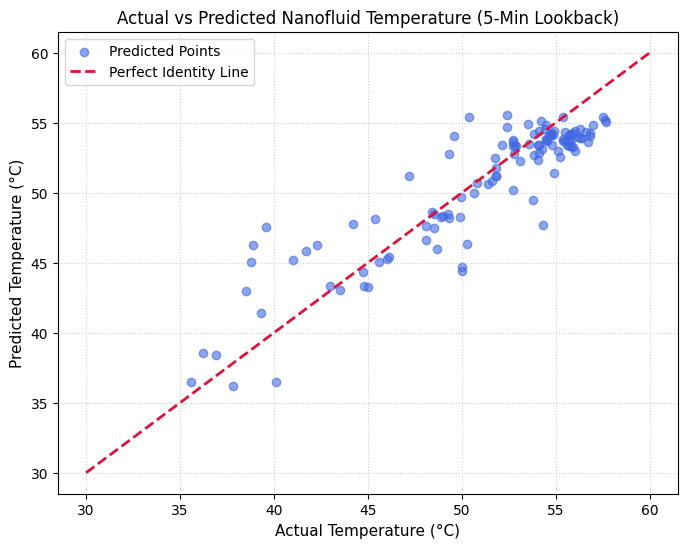

In [47]:
# ==========================================
# 7. Visualization Plotting
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, color='royalblue', alpha=0.6, label='Predicted Points')
plt.plot([30, 60], [30, 60], color='crimson', linestyle='--', linewidth=2, label='Perfect Identity Line')
plt.xlabel("Actual Temperature (°C)", fontsize=11)
plt.ylabel("Predicted Temperature (°C)", fontsize=11)
plt.title("Actual vs Predicted Nanofluid Temperature (5-Min Lookback)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()